In [1]:
import sys, os

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from src.get_data import load_data
from src.models.poisson_baseline.baseline_main import (
    fit_poisson_glm,
    fit_poisson_xgboost,
)
from src.models.poisson_nn.nn_main import (
    fit_poisson_nn,
    fit_poisson_nn_transfer_learning,
)
from src.models.utils import summarise_model_results
from src.visualisation import (
    compare_models_for_cell,
    compare_r2_across_cells,
    plot_training_curves,
    plot_ytrue_vs_ypred,
)
from src.models.hyperparam_search import grid_search_per_cell
from src.models.poisson_nn.nn_models import PoissonNN
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import PoissonRegressor
from xgboost import XGBRegressor

In [4]:
filenames = ["test1.mat", "test2.mat", "test3.mat", "test4.mat"]
X, Y, cell_ids, rec_ids = load_data("../data/simulated", filenames)

In [5]:
X.shape, Y.shape, cell_ids.shape, rec_ids.shape

((5, 60000), (60000,), (60000,), (60000,))

In [5]:
# baseline models
# Linear Baseline (GLM), Non-linear Baseline (XGBoost)
glm_results = fit_poisson_glm(X, Y, cell_ids, grid_search=True)
xgboost_results = fit_poisson_xgboost(X, Y, cell_ids, grid_search=True)

In [6]:
summarise_model_results(glm_results["results"], model_name="Poisson GLM")


===== Poisson GLM Summary =====

--- Cell 0.0 ---
Train pseudo-R²:       0.4315
Train log-likelihood:  11061.93
Train deviance:        6.74
Val pseudo-R²:         0.4740
Val log-likelihood:    2301.52
Val deviance:          6.29
Test pseudo-R²:        0.5115
Test log-likelihood:   3256.04
Test deviance:         7.41

--- Cell 1.0 ---
Train pseudo-R²:       0.4300
Train log-likelihood:  11217.13
Train deviance:        6.87
Val pseudo-R²:         0.4718
Val log-likelihood:    2337.34
Val deviance:          6.26
Test pseudo-R²:        0.5064
Test log-likelihood:   3052.80
Test deviance:         7.29

--- Cell 2.0 ---
Train pseudo-R²:       0.4335
Train log-likelihood:  11268.28
Train deviance:        6.59
Val pseudo-R²:         0.4556
Val log-likelihood:    2273.83
Val deviance:          6.49
Test pseudo-R²:        0.5150
Test log-likelihood:   2831.73
Test deviance:         6.77

--- Cell 3.0 ---
Train pseudo-R²:       0.4229
Train log-likelihood:  10966.56
Train deviance:        6.79
V

In [7]:
glm_results["best_params"]

{0.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 1.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 2.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 3.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 4.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 10.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 11.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 12.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 13.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 14.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 25.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 26.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 27.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 28.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 29.0: {'model_params': {'alpha': 0.1}, 'trainer_params': {}},
 45.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {

In [8]:
summarise_model_results(xgboost_results["results"], model_name="Poisson XGBoost")


===== Poisson XGBoost Summary =====

--- Cell 0.0 ---
Train pseudo-R²:       0.8704
Train log-likelihood:  16527.43
Train deviance:        1.54
Val pseudo-R²:         0.8072
Val log-likelihood:    3198.64
Val deviance:          2.31
Test pseudo-R²:        0.7658
Test log-likelihood:   4123.80
Test deviance:         3.55

--- Cell 1.0 ---
Train pseudo-R²:       0.8721
Train log-likelihood:  16809.31
Train deviance:        1.54
Val pseudo-R²:         0.7806
Val log-likelihood:    3161.22
Val deviance:          2.60
Test pseudo-R²:        0.7638
Test log-likelihood:   3908.56
Test deviance:         3.49

--- Cell 2.0 ---
Train pseudo-R²:       0.8702
Train log-likelihood:  16600.22
Train deviance:        1.51
Val pseudo-R²:         0.7785
Val log-likelihood:    3140.46
Val deviance:          2.64
Test pseudo-R²:        0.7634
Test log-likelihood:   3611.92
Test deviance:         3.30

--- Cell 3.0 ---
Train pseudo-R²:       0.8672
Train log-likelihood:  16456.14
Train deviance:        1.

In [9]:
xgboost_results["best_params"]

{0.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 1.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 2.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 3.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 4.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 10.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 11.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 12.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
   'n_estimators': 200},
  'trainer_params': {}},
 13.0: {'model_params': {'learning_rate': 0.05,
   'max_depth': 5,
  

In [10]:
nn_model_param_grid = {
    "hidden_sizes": [  # optimise no. of layers and units per layer
        (16,),
        (32,),
        (64,),
        (64, 32),
    ]
}
nn_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4, 1e-3],  # optimise l1 regularisation strength
}

In [ ]:
nn_results = fit_poisson_nn(
    X,
    Y,
    cell_ids,
    batch_size="auto",
    epochs=30,  # for grid search only
    scaler=StandardScaler,
    grid_search=True,
    k_folds=2,
    model_param_grid=nn_model_param_grid,
    trainer_param_grid=nn_trainer_param_grid,
)

In [12]:
summarise_model_results(nn_results["results"], model_name="Poisson Neural Network")


===== Poisson Neural Network Summary =====

--- Cell 0.0 ---
Train pseudo-R²:       0.9033
Train log-likelihood:  16936.16
Train deviance:        1.15
Val pseudo-R²:         0.9033
Val log-likelihood:    3457.35
Val deviance:          1.16
Test pseudo-R²:        0.8941
Test log-likelihood:   4561.56
Test deviance:         1.60

--- Cell 1.0 ---
Train pseudo-R²:       0.8414
Train log-likelihood:  16421.33
Train deviance:        1.91
Val pseudo-R²:         0.8364
Val log-likelihood:    3310.34
Val deviance:          1.94
Test pseudo-R²:        0.8298
Test log-likelihood:   4127.71
Test deviance:         2.52

--- Cell 2.0 ---
Train pseudo-R²:       0.8410
Train log-likelihood:  16243.02
Train deviance:        1.85
Val pseudo-R²:         0.7934
Val log-likelihood:    3180.35
Val deviance:          2.46
Test pseudo-R²:        0.8265
Test log-likelihood:   3810.29
Test deviance:         2.42

--- Cell 3.0 ---
Train pseudo-R²:       0.8883
Train log-likelihood:  16716.76
Train deviance:   

In [13]:
nn_results["best_params"]

{0.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 0.0}},
 1.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 0.0}},
 2.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 0.0}},
 3.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 0.0}},
 4.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 0.0}},
 10.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 0.0}},
 11.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 0.0}},
 12.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 0.0}},
 13.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 0.0}},
 14.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l1_lambda': 0.0}},
 25.0: {'model_params': {'hidden_sizes': (64, 32)},
  'trainer_params': {'l

In [14]:
nn_results["results"][0].keys()

dict_keys(['model', 'scaler', 'train', 'val', 'test', 'y_pred_train', 'y_pred_val', 'y_pred_test', 'y_train', 'y_val', 'y_test', 'train_losses', 'val_losses'])

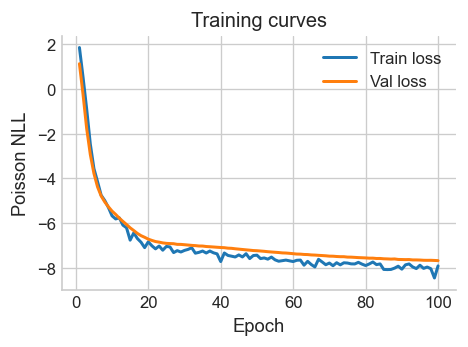

In [15]:
plot_training_curves(
    train_losses=nn_results["results"][0]["train_losses"],
    val_losses=nn_results["results"][0]["val_losses"],
)

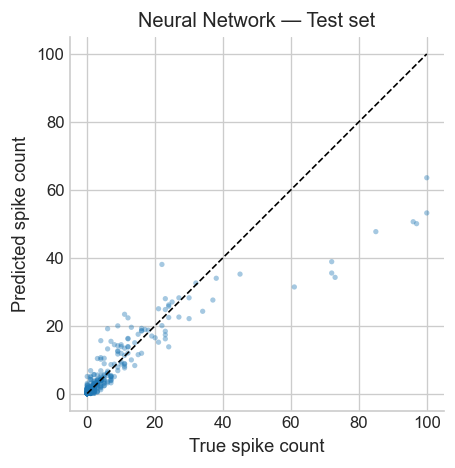

In [16]:
plot_ytrue_vs_ypred(
    y_true=nn_results["results"][0]["y_test"],
    y_pred=nn_results["results"][0]["y_pred_test"],
    title="Neural Network — Test set",
)

In [ ]:
nn_nogs_results = fit_poisson_nn(
    X,
    Y,
    cell_ids,
    hidden_sizes=[64, 32],
    l1_lambda=0.0,
    batch_size="auto",
    scaler=StandardScaler,
    grid_search=False,
)

In [11]:
summarise_model_results(
    nn_nogs_results["results"], model_name="Poisson Neural Network 2"
)


===== Poisson Neural Network 2 Summary =====

--- Cell 0.0 ---
Train pseudo-R²:       0.8623
Train log-likelihood:  16426.18
Train deviance:        1.63
Val pseudo-R²:         0.8531
Val log-likelihood:    3322.34
Val deviance:          1.76
Test pseudo-R²:        0.8419
Test log-likelihood:   4383.24
Test deviance:         2.40

--- Cell 1.0 ---
Train pseudo-R²:       0.9072
Train log-likelihood:  17253.60
Train deviance:        1.12
Val pseudo-R²:         0.8933
Val log-likelihood:    3462.02
Val deviance:          1.27
Test pseudo-R²:        0.9019
Test log-likelihood:   4367.50
Test deviance:         1.45

--- Cell 2.0 ---
Train pseudo-R²:       0.9053
Train log-likelihood:  17027.84
Train deviance:        1.10
Val pseudo-R²:         0.8737
Val log-likelihood:    3395.75
Val deviance:          1.51
Test pseudo-R²:        0.8893
Test log-likelihood:   4007.53
Test deviance:         1.55

--- Cell 3.0 ---
Train pseudo-R²:       0.8953
Train log-likelihood:  16803.87
Train deviance: 

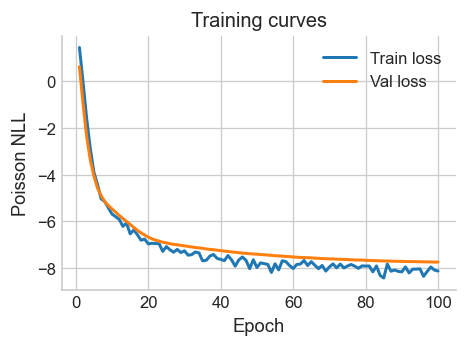

In [8]:
plot_training_curves(
    train_losses=nn_nogs_results["results"][0]["train_losses"],
    val_losses=nn_nogs_results["results"][0]["val_losses"],
)

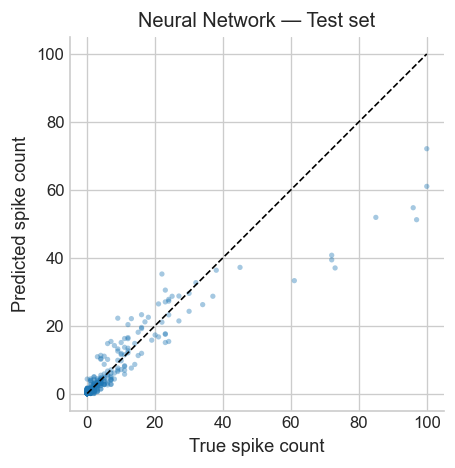

In [9]:
plot_ytrue_vs_ypred(
    y_true=nn_nogs_results["results"][0]["y_test"],
    y_pred=nn_nogs_results["results"][0]["y_pred_test"],
    title="Neural Network — Test set",
)

In [17]:
tl_model_param_grid = {
    "hidden_sizes": [
        (16,),
        (32,),
        (64,),
        (64, 32),
    ]
}
tl_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4],
}

In [ ]:
nn_tl_results = fit_poisson_nn_transfer_learning(
    X,
    Y,
    cell_ids,
    batch_size="auto",
    scaler=StandardScaler,
    grid_search=True,
    model_param_grid=tl_model_param_grid,
    trainer_param_grid=tl_trainer_param_grid,
)

In [19]:
nn_tl_results["results"][0].keys()

dict_keys(['model', 'cell_head_index', 'y_test', 'y_pred_test', 'test', 'train', 'val', 'train_losses', 'val_losses'])

In [20]:
summarise_model_results(
    nn_tl_results["results"], model_name="Poisson Neural Network - Transfer Learning"
)


===== Poisson Neural Network - Transfer Learning Summary =====

--- Cell 0.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.1033
Test log-likelihood:   1863.80
Test deviance:         13.59

--- Cell 1.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.1772
Test log-likelihood:   1958.58
Test deviance:         12.16

--- Cell 2.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.1213
Test log-likelihood:   1595.12
Test deviance:         12.27

--- Cell 3.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.1375
Test log-likelihood:   1771.66
Test deviance:         12.42

--- Cell 4.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.1744
Test log-likelihood:   2004.67
Test deviance:         12.17

--- C

In [21]:
nn_tl_results["best_params"]

{'model_params': {'hidden_sizes': (64, 32)},
 'trainer_params': {'l1_lambda': 0.0}}

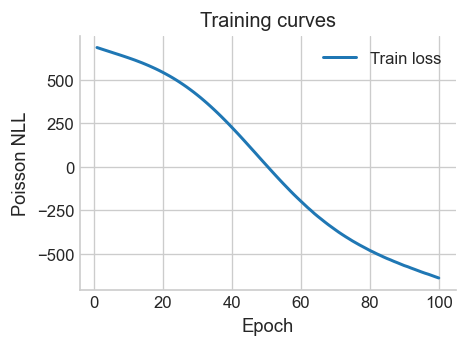

In [22]:
plot_training_curves(
    train_losses=nn_tl_results["results"][0]["train_losses"],
)

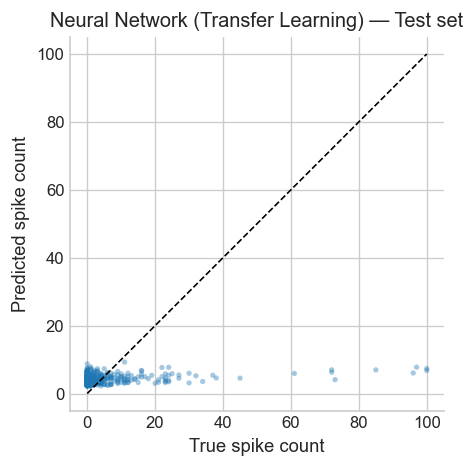

In [23]:
plot_ytrue_vs_ypred(
    y_true=nn_tl_results["results"][0]["y_test"],
    y_pred=nn_tl_results["results"][0]["y_pred_test"],
    title="Neural Network (Transfer Learning) — Test set",
)

In [ ]:
nn_tl_nogs_results = fit_poisson_nn_transfer_learning(
    X,
    Y,
    cell_ids,
    hidden_sizes=[64, 32],
    l1_lambda=0.0,
    batch_size="auto",
    scaler=StandardScaler,
    grid_search=False,
)

In [25]:
summarise_model_results(
    nn_tl_nogs_results["results"],
    model_name="Poisson Neural Network - Transfer Learning 2",
)


===== Poisson Neural Network - Transfer Learning 2 Summary =====

--- Cell 0.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.3876
Test log-likelihood:   2833.64
Test deviance:         9.28

--- Cell 1.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.3442
Test log-likelihood:   2513.87
Test deviance:         9.69

--- Cell 2.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.3858
Test log-likelihood:   2425.95
Test deviance:         8.57

--- Cell 3.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.4027
Test log-likelihood:   2630.79
Test deviance:         8.60

--- Cell 4.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.3347
Test log-likelihood:   2536.14
Test deviance:         9.81

--- Cell

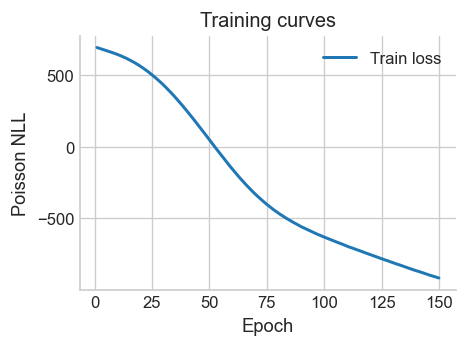

In [26]:
plot_training_curves(
    train_losses=nn_tl_nogs_results["results"][0]["train_losses"],
)

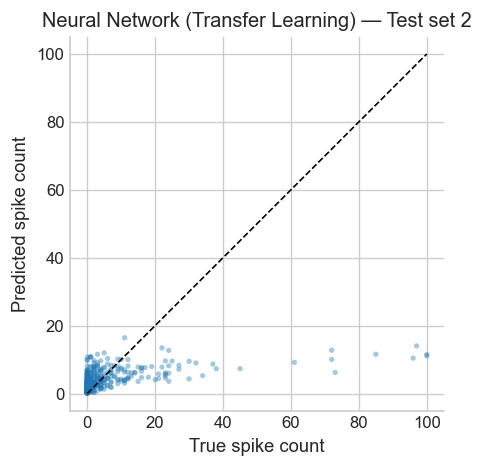

In [27]:
plot_ytrue_vs_ypred(
    y_true=nn_tl_nogs_results["results"][0]["y_test"],
    y_pred=nn_tl_nogs_results["results"][0]["y_pred_test"],
    title="Neural Network (Transfer Learning) — Test set 2",
)

In [28]:
cells = sorted(glm_results["results"].keys())

glm_r2 = [glm_results["results"][c]["test"]["pseudo_r2"] for c in cells]
xgb_r2 = [xgboost_results["results"][c]["test"]["pseudo_r2"] for c in cells]
nn_r2 = [nn_results["results"][c]["test"]["pseudo_r2"] for c in cells]
nn_tl_r2 = [nn_tl_nogs_results["results"][c]["test"]["pseudo_r2"] for c in cells]

In [29]:
df_test_perf = pd.DataFrame(
    {
        "cell": cells,
        "glm_r2": glm_r2,
        "xgb_r2": xgb_r2,
        "nn_r2": nn_r2,
        "nn_tl_r2": nn_tl_r2,
    }
)

df_test_perf

,cell,glm_r2,xgb_r2,nn_r2,nn_tl_r2
0,0.0,0.511454,0.765825,0.894146,0.387634
1,1.0,0.506373,0.763823,0.829754,0.344238
2,2.0,0.514983,0.763364,0.826517,0.385799
3,3.0,0.497466,0.759938,0.892575,0.402653
4,4.0,0.501561,0.756861,0.894755,0.334687
5,10.0,0.412066,0.704449,0.772279,0.286268
6,11.0,0.428756,0.716208,0.787255,0.243133
7,12.0,0.467753,0.727279,0.799509,0.303532
8,13.0,0.448820,0.718115,0.809273,0.258668
9,14.0,0.425786,0.684994,0.761432,0.226613


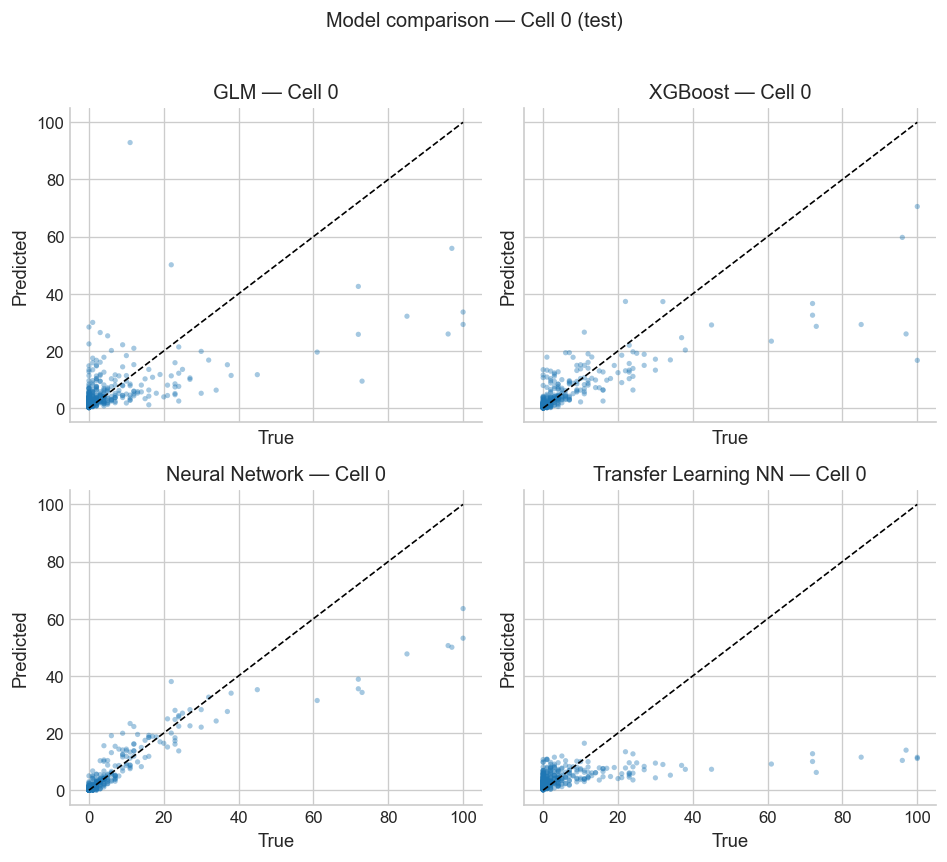

In [30]:
compare_models_for_cell(
    glm_results["results"],
    xgboost_results["results"],
    nn_results["results"],
    nn_tl_nogs_results["results"],
    cell=0,
)

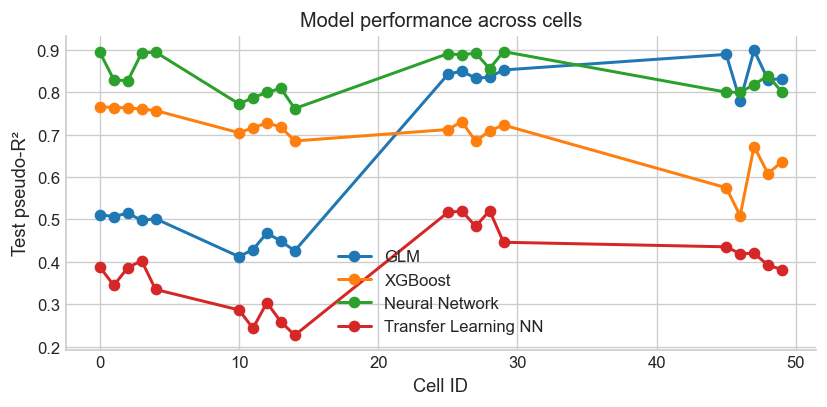

In [31]:
compare_r2_across_cells(
    glm_results["results"],
    xgboost_results["results"],
    nn_results["results"],
    nn_tl_nogs_results["results"],
    split="test",
)

In [32]:
# TODO - FIX TRRAINING LOOP FOR TRANSFER LEARNING, ESPECIALLY GRID SEARCH, TRY WITHOUT GRID SEARCH FIRST TO DEBUG
# TODO - UPFATE FIT FUNCTION FOR EACH MODEL TO PASS UNIQUE PARAMETERS FOR EACH CELL'S MODEL INSTEAD OF A GLOBAL PARAMETER SET FOR ALL CELLS